In [1]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic
from popsycle import utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
import synthpop
import pdb
import time

In [2]:
sp_mod = synthetic.run_synthpop('huston2025_defaults.synthpop_conf', # set default figuration, then set any overrides as kwargs
                           output_location="synthpop_output",  # where to place the synthpop output
                           obsmag = False, # keep magnitudes in absolute
                           output_filename_pattern="{name_for_output}_l{l_deg:.3f}_b{b_deg:.3f}", #how to name the output
                           post_processing_kwargs = [{"name": "popsycle_post_processing"}], # Module to format catalog for PopSyCLE
                           chosen_bands=["Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I", "2MASS_J", "2MASS_H", "2MASS_Ks"],
                           maglim=['Bessell_U',99,'keep'],
                           multiplicity_kwargs={"name":"Raghavan"},
                           extinction_map_kwargs = {"name":"maps_from_dustmaps", "dustmap_name":"marshall"}, #{"name":"surot"}
                               name_for_output='synthpopsycle_multiples', l_deg=1, b_deg=-1.2, field_shape='box', 
                               field_scale=0.008, field_scale_unit='deg', save_data=False
                          )

 9509 - Execution Date: 2025-12-19 00:18:34


################################ Settings #################################
 9515 - # reading default parameters from
 9517 - default_config_file =  /u/shepbrooke/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 9521 - # read configuration from 
 9524 - config_file = '/u/shepbrooke/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 9527 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "Huston2025",
    "model_name": "Huston2025",
    "field_shape": "circle",
    "field_scale": null,
    "field_scale_unit": "deg",
    "random_seed": 702532145,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,


** Generating synthpopsycle_multiples_synthpop_params.txt **
-- configFile huston2025_defaults.synthpop_conf
-- nameForOutput synthpopsycle_multiples
-- l 1
-- b -1.2
-- fieldScale 0.008
-- fieldScaleUnit deg
-- fieldShape box




# Population 1;  halo -----------------------------------------------------
 15764 - # Initialize Population 1 (halo) from 
 15766 - pop_file = '/u/shepbrooke/code/synthpop/synthpop/models/Huston2025/halo.popjson'


# Population 2;  nsd ------------------------------------------------------
 17546 - # Initialize Population 2 (nsd) from 
 17548 - pop_file = '/u/shepbrooke/code/synthpop/synthpop/models/Huston2025/nsd.popjson'


# Population 3;  thick_disk -----------------------------------------------
 20428 - # Initialize Population 3 (thick_disk) from 
 20430 - pop_file = '/u/shepbrooke/code/synthpop/synthpop/models/Huston2025/thick_disk.popjson'


# Population 4;  thin_disk_1 ----------------------------------------------
 22363 - # Initialize Population 4 (thin_disk_1) from 
 22364 - pop_file = '/u/shepbrooke/code/synthpop/synthpop/models/Huston2025/thin_disk_1.popjson'


# Population 5;  thin_disk_2 ----------------------------------------------
 24059 - # Initialize Population 5

In [3]:
synthetic.calc_events(hdf5_file = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc.h5", 
                      hdf5_file_comp = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_companions.h5", 
                      output_root2 = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc",  
                      radius_cut = 2, obs_time = 1000,  n_obs = 11,  
                      theta_frac = 2,  blend_rad = 0.65,  overwrite = True,  n_proc = 4)

Working on loop ll, bb =  0 0
Working on loop ll, bb =  0 1
Working on loop ll, bb =  1 0
Working on loop ll, bb =  1 1
No events!
calc_events runtime : 7.948093 s


In [4]:
synthetic.refine_events(input_root = 'synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc',
                        hdf5_file_comp = 'synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_companions.h5',
                        filter_dict={'ubv':['I']},
                        red_law = 'Damineli16', 
                        overwrite = True, 
                        output_file = 'default',
                        galactic_model_code = 'synthpop')

Original candidate events:  4065
Candidate events in survey window:  425
On square l0b0
On square l0b1
On square l0b2
On square l1b0
On square l1b1
On square l1b2
On square l2b0
On square l2b1
On square l2b2
refine_events runtime : 1.886804 s


In [5]:
synthetic.refine_binary_events(events="synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16.fits", 
                               companions = "synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16_companions.fits", 
                               filter_name = 'I',
                               photometric_system = 'ubv', 
                               overwrite = True,
                               n_proc=1,
                               output_file = 'default', 
                               save_phot = True, 
                               phot_dir = 'example_bin_phot')

/u/shepbrooke/code/PopSyCLE/popsycle/binary_utils.py:66: RuntimeWarning: invalid value encountered in log10
  m_diff = -2.5*np.log10(f1 - f2)
/u/shepbrooke/code/PopSyCLE/popsycle/binary_utils.py:76: UserWarning: Warning: first magnitude dimmer than second magnitude. Result will be nan.
  warnings.warn("Warning: first magnitude dimmer than second magnitude. Result will be nan.")
/u/shepbrooke/code/BAGLE_Microlensing/src/bagle/model.py:16741: RuntimeWarning: invalid value encountered in divide
  dwbardz = self.m1 / (z_arr - z1[:, np.newaxis, np.newaxis]) ** 2
/u/shepbrooke/code/BAGLE_Microlensing/src/bagle/model.py:16742: RuntimeWarning: invalid value encountered in divide
  dwbardz += self.m2 / (z_arr - z2[:, np.newaxis, np.newaxis]) ** 2
/u/shepbrooke/code/BAGLE_Microlensing/src/bagle/model.py:16741: RuntimeWarning: invalid value encountered in divide
  dwbardz = self.m1 / (z_arr - z1[:, np.newaxis, np.newaxis]) ** 2
/u/shepbrooke/code/BAGLE_Microlensing/src/bagle/model.py:16742: Runti

refine_binary_events runtime : 208.772061 s


In [6]:
t = Table.read('synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16_rb.fits')
print(t.colnames)

bin = Table.read('synthpop_output/synthpopsycle_multiples_l1.000_b-1.200_psc_refined_events_ubv_I_Damineli16_companions_rb.fits')
print(bin.colnames)

['obj_id_L', 'obj_id_S', 'zams_mass_L', 'age_L', 'N_companions_L', 'mass_L', 'teff_L', 'ubv_I_L', 'grav_L', 'ubv_U_L', 'ubv_R_L', 'feh_L', 'ubv_V_L', 'ubv_B_L', 'px_L', 'py_L', 'pz_L', 'rad_L', 'glon_L', 'glat_L', 'vr_L', 'mu_lcosb_L', 'mu_b_L', 'vx_L', 'vy_L', 'vz_L', 'popid_L', 'isMultiple_L', 'exbv_L', 'mbol_L', 'systemMass_L', 'rem_id_L', 'sep_L', 'zams_mass_S', 'age_S', 'N_companions_S', 'mass_S', 'teff_S', 'ubv_I_S', 'grav_S', 'ubv_U_S', 'ubv_R_S', 'feh_S', 'ubv_V_S', 'ubv_B_S', 'px_S', 'py_S', 'pz_S', 'rad_S', 'glon_S', 'glat_S', 'vr_S', 'mu_lcosb_S', 'mu_b_S', 'vx_S', 'vy_S', 'vz_S', 'popid_S', 'isMultiple_S', 'exbv_S', 'mbol_S', 'systemMass_S', 'rem_id_S', 'sep_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed', 'n_peaks', 'bin_delta_m', 'tE_sys', 'tE_primary', 'primary_t', 'avg_t', 'std_t', 'asymmetry', 'companion_idx_list

In [7]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 0
Number of NSs: 1
Number of WDs: 51
Number of stars: 373


Text(0.5, 0, '$t_E$ (days)')

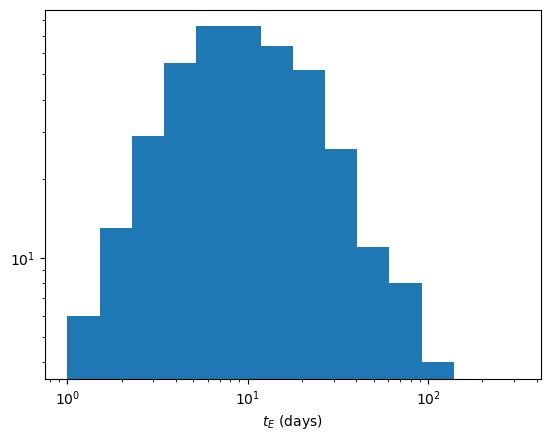

In [8]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

Text(0.5, 0, '$t_E$ (days)')

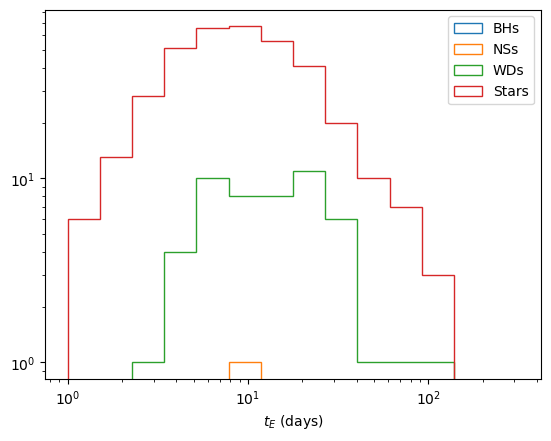

In [9]:
bh_idx = t[t['rem_id_L'] == 103]
ns_idx = t[t['rem_id_L'] == 102]
wd_idx = t[t['rem_id_L'] == 101]
st_idx = t[t['rem_id_L'] == 0]

plt.hist(bh_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="BHs")
plt.hist(ns_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="NSs")
plt.hist(wd_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="WDs")
plt.hist(st_idx['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Stars")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('$t_E$ (days)')

Text(0.5, 0, '$t_E$ (days)')

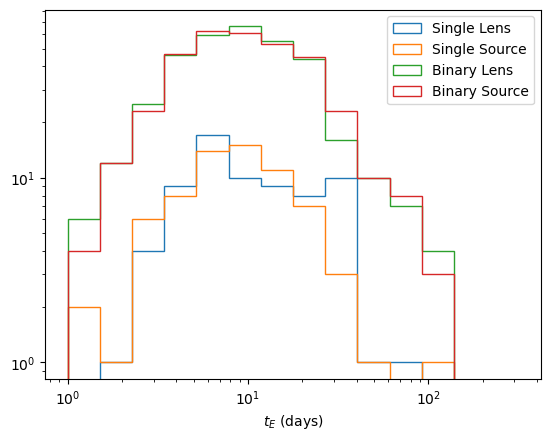

In [10]:
no_companions_lens = t[t['N_companions_L'] == 0]
no_companions_source = t[t['N_companions_S'] == 0]
companions_lens = t[t['N_companions_L'] != 0]
companions_source= t[t['N_companions_S'] != 0]

plt.hist(no_companions_lens['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Single Lens")
plt.hist(no_companions_source['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Single Source")
plt.hist(companions_lens['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Binary Lens")
plt.hist(companions_source['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Binary Source")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('$t_E$ (days)')

Text(0.5, 0, '$t_E$ (days)')

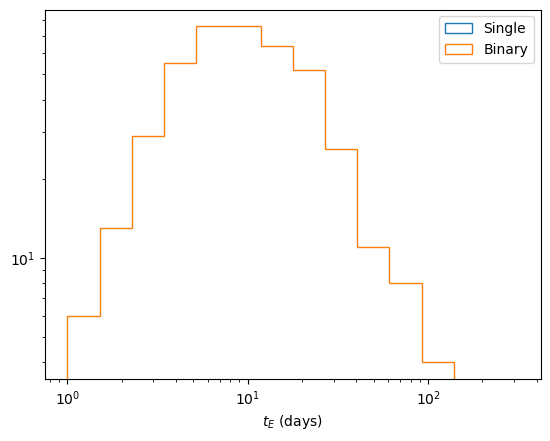

In [11]:
single = no_companions_lens[no_companions_lens['N_companions_S'] == 0]
plbs = no_companions_lens[no_companions_lens['N_companions_S'] != 0]
blps = no_companions_source[no_companions_source['N_companions_L'] != 0]
blbs = companions_source[companions_source['N_companions_L'] != 0]

binary = vstack([plbs, blps, blbs])

plt.hist(single['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Single")
plt.hist(binary['t_E'], bins = np.logspace(0, 2.5, 15),histtype=u'step', label="Binary")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('$t_E$ (days)')

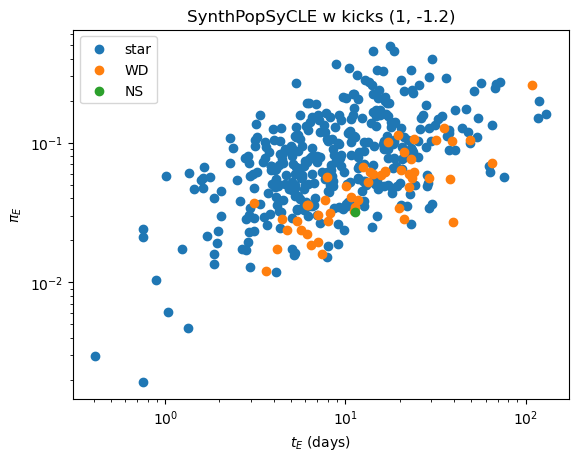

In [12]:
lens_type={0:'star', 101:'WD', 102:'NS', 103:'BH'}
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['t_E'][idxs], t['pi_E'][idxs], label=lens_type[rem_id])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')
plt.legend(loc=2)
plt.title('SynthPopSyCLE w kicks (1, -1.2)')
plt.savefig('synthpopsycle_lenstype_multiples.png')

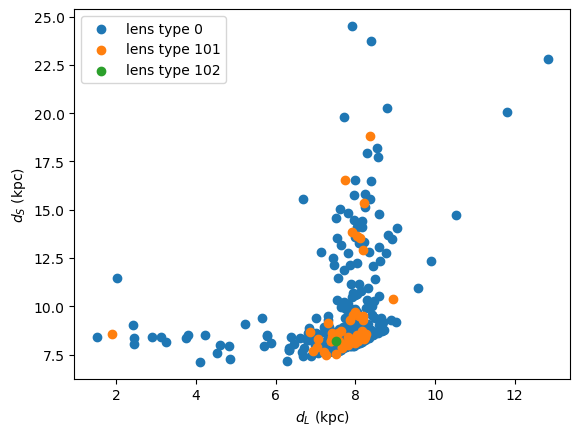

In [13]:
for rem_id in np.unique(t['rem_id_L']):
    idxs = np.where(t['rem_id_L']==rem_id)[0]
    plt.scatter(t['rad_L'][idxs], t['rad_S'][idxs], label='lens type '+str(rem_id))
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')
plt.legend()